In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:

movie = pd.read_csv('Downloads/movie.csv')
ratings = pd.read_csv('Downloads/archive/ratings.csv')
strm_n = pd.read_csv('Downloads/UNCLEANED_NETFLIX_LATEST_DATASET.csv')
streaming_vs = pd.read_csv('Downloads/sample_streaming_viewership_data.csv')

In [4]:

movie.describe

<bound method NDFrame.describe of       Unnamed: 0      id                title  \
0              0  960258           Shark Bait   
1              1   11067      Major League II   
2              2   20856  Aliens in the Attic   
3              3   14098             100 Feet   
4              4   11398       The Art of War   
...          ...     ...                  ...   
8575        8575   10723          Bulletproof   
8576        8576  397422          Rough Night   
8577        8577   70435              Haywire   
8578        8578   36599           Prom Night   
8579        8579   23410             The Thaw   

                                               overview release_date  \
0     A group of friends enjoying a weekend steal a ...   2022-05-13   
1     After losing in the ALCS the year before, the ...   1994-03-30   
2     A group of kids must protect their vacation ho...   2009-07-30   
3     After Marnie Watson kills her abusive husband ...   2008-07-22   
4     Neil Shaw i

In [14]:
movie.dtypes

Unnamed: 0        int64
id                int64
title            object
overview         object
release_date     object
popularity      float64
vote_average    float64
vote_count        int64
dtype: object

In [15]:
movie.shape

(8580, 8)

In [26]:
ratings.dtypes

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

In [27]:
ratings.describe

<bound method NDFrame.describe of           userId  movieId  rating   timestamp
0              1      110     1.0  1425941529
1              1      147     4.5  1425942435
2              1      858     5.0  1425941523
3              1     1221     5.0  1425941546
4              1     1246     5.0  1425941556
...          ...      ...     ...         ...
26024284  270896    58559     5.0  1257031564
26024285  270896    60069     5.0  1257032032
26024286  270896    63082     4.5  1257031764
26024287  270896    64957     4.5  1257033990
26024288  270896    71878     2.0  1257031858

[26024289 rows x 4 columns]>

In [5]:
movie.info

<bound method DataFrame.info of       Unnamed: 0      id                title  \
0              0  960258           Shark Bait   
1              1   11067      Major League II   
2              2   20856  Aliens in the Attic   
3              3   14098             100 Feet   
4              4   11398       The Art of War   
...          ...     ...                  ...   
8575        8575   10723          Bulletproof   
8576        8576  397422          Rough Night   
8577        8577   70435              Haywire   
8578        8578   36599           Prom Night   
8579        8579   23410             The Thaw   

                                               overview release_date  \
0     A group of friends enjoying a weekend steal a ...   2022-05-13   
1     After losing in the ALCS the year before, the ...   1994-03-30   
2     A group of kids must protect their vacation ho...   2009-07-30   
3     After Marnie Watson kills her abusive husband ...   2008-07-22   
4     Neil Shaw is 

In [13]:
strm_n.info

<bound method DataFrame.info of                                 title   type                     genres  \
0                               Ariel  movie       Comedy, Crime, Drama   
1                 Shadows in Paradise  movie       Comedy, Drama, Music   
2                        Forrest Gump  movie             Drama, Romance   
3                     American Beauty  movie                      Drama   
4                   The Fifth Element  movie  Action, Adventure, Sci-Fi   
...                               ...    ...                        ...   
21845      Cheat: Unfinished Business     tv                 Reality-TV   
21846  Cold Case: The Tylenol Murders     tv         Crime, Documentary   
21847                             NaN     tv  Animation, Crime, Mystery   
21848                             NaN     tv                        NaN   
21849                       Entrapped     tv      Crime, Drama, Mystery   

       releaseYear      imdbId  imdbAverageRating  imdbNumVotes  
0

In [17]:
strm_n.describe

<bound method NDFrame.describe of                                 title   type                     genres  \
0                               Ariel  movie       Comedy, Crime, Drama   
1                 Shadows in Paradise  movie       Comedy, Drama, Music   
2                        Forrest Gump  movie             Drama, Romance   
3                     American Beauty  movie                      Drama   
4                   The Fifth Element  movie  Action, Adventure, Sci-Fi   
...                               ...    ...                        ...   
21845      Cheat: Unfinished Business     tv                 Reality-TV   
21846  Cold Case: The Tylenol Murders     tv         Crime, Documentary   
21847                             NaN     tv  Animation, Crime, Mystery   
21848                             NaN     tv                        NaN   
21849                       Entrapped     tv      Crime, Drama, Mystery   

       releaseYear      imdbId  imdbAverageRating  imdbNumVotes  

In [18]:
strm_n['genres']

0             Comedy, Crime, Drama
1             Comedy, Drama, Music
2                   Drama, Romance
3                            Drama
4        Action, Adventure, Sci-Fi
                   ...            
21845                   Reality-TV
21846           Crime, Documentary
21847    Animation, Crime, Mystery
21848                          NaN
21849        Crime, Drama, Mystery
Name: genres, Length: 21850, dtype: object

In [19]:
strm_n.dtypes

title                 object
type                  object
genres                object
releaseYear          float64
imdbId                object
imdbAverageRating    float64
imdbNumVotes         float64
dtype: object

In [23]:
strm_n['genres'],['imdbAverageRating']
strm_n.head(10)

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes
0,Ariel,movie,"Comedy, Crime, Drama",1988.0,tt0094675,7.4,9216.0
1,Shadows in Paradise,movie,"Comedy, Drama, Music",1986.0,tt0092149,7.4,8043.0
2,Forrest Gump,movie,"Drama, Romance",1994.0,tt0109830,8.8,2386121.0
3,American Beauty,movie,Drama,1999.0,tt0169547,8.3,1250986.0
4,The Fifth Element,movie,"Action, Adventure, Sci-Fi",1997.0,tt0119116,7.6,528190.0
5,Jarhead,movie,"Biography, Drama, War",2005.0,tt0418763,7.0,216106.0
6,Unforgiven,movie,"Drama, Western",1992.0,tt0105695,8.2,455519.0
7,Eternal Sunshine of the Spotless Mind,movie,"Drama, Romance, Sci-Fi",2004.0,tt0338013,8.3,1139345.0
8,Amores Perros,movie,"Drama, Thriller",2000.0,tt0245712,8.0,268218.0
9,A History of Violence,movie,"Action, Crime, Drama",2005.0,tt0399146,7.4,264964.0


In [85]:
filtered_strm_n = strm_n[strm_n['releaseYear'] > 2022]
genre_ratings = filtered_strm_n.groupby('genres')['imdbAverageRating'].mean() 

In [86]:
top_5_genres = genre_ratings.sort_values(ascending=False).head(5)
bottom_5_genres = genre_ratings.sort_values().head(5)


In [87]:
print("Top 5 Highest-Rated Genres:")
print(top_5_genres)

print("\nTop 5 Lowest-Rated Genres:")
print(bottom_5_genres)

Top 5 Highest-Rated Genres:
genres
History, Horror, Romance             9.0
Comedy, Fantasy, Music               8.6
Family, Music, Reality-TV            8.6
Drama, Family, Mystery               8.1
Animation, Biography, Documentary    8.1
Name: imdbAverageRating, dtype: float64

Top 5 Lowest-Rated Genres:
genres
Action, Reality-TV, Sport    2.90
Crime, Drama, Horror         3.15
Action, Drama, Fantasy       3.50
Comedy, Horror, Music        3.50
Action, Drama, Musical       3.80
Name: imdbAverageRating, dtype: float64


In [49]:
genre_ratings = strm_n.groupby('genres')['imdbAverageRating'].mean() 

In [50]:
top_5_genres = genre_ratings.sort_values(ascending=False).head(5)
bottom_5_genres = genre_ratings.sort_values().head(5)


In [51]:
print("Top 5 Highest-Rated Genres:")
print(top_5_genres)

print("\nTop 5 Lowest-Rated Genres:")
print(bottom_5_genres)

Top 5 Highest-Rated Genres:
genres
Documentary, Family, Reality-TV    9.1
History, Horror, Romance           9.0
Family, Talk-Show                  8.7
Family, Music, Reality-TV          8.6
Comedy, Music, Talk-Show           8.4
Name: imdbAverageRating, dtype: float64

Top 5 Lowest-Rated Genres:
genres
Family, Game-Show               2.8
Fantasy, Horror, Short          4.0
Fantasy, Music                  4.0
Action, Romance, Sci-Fi         4.0
Comedy, Documentary, Musical    4.0
Name: imdbAverageRating, dtype: float64


In [125]:
genres = streaming_vs['Genre'].unique()
print(genres)

['Sci-Fi' 'Comedy' 'Documentary' 'Action' 'Drama' 'Thriller']


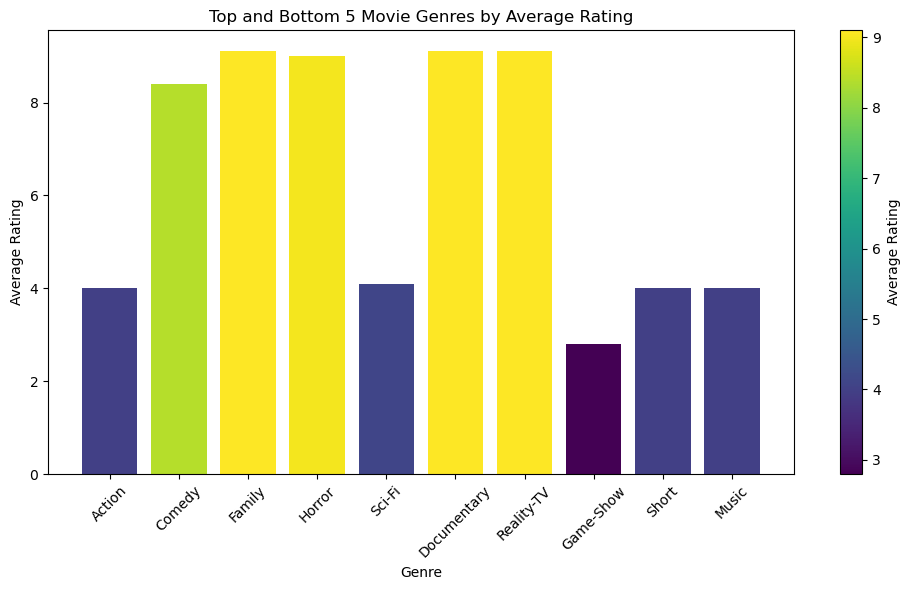

In [92]:
genres = ['Action', 'Comedy', 'Family', 'Horror', 'Sci-Fi', 'Documentary', 'Reality-TV', 'Game-Show', 'Short', 'Music']
ratings = [4.0, 8.4, 9.1, 9.0, 4.1, 9.1, 9.1, 2.8, 4.0, 4.0]

# Normalize ratings for color mapping
norm = plt.Normalize(min(ratings), max(ratings))
colors = plt.cm.viridis(norm(ratings))

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart with colors
bars = ax.bar(genres, ratings, color=colors)

# Add title and labels
ax.set_title('Top and Bottom 5 Movie Genres by Average Rating')
ax.set_xlabel('Genre')
ax.set_ylabel('Average Rating')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Average Rating')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
streaming_vs.dtypes


User_ID                        object
Session_ID                     object
Device_ID                       int64
Video_ID                        int64
Duration_Watched (minutes)    float64
Genre                          object
Country                        object
Age                             int64
Gender                         object
Subscription_Status            object
Ratings                         int64
Languages                      object
Device_Type                    object
Location                       object
Playback_Quality               object
Interaction_Events              int64
dtype: object

In [90]:
streaming_vs.head()

,User_ID,Session_ID,Device_ID,Video_ID,Duration_Watched (minutes),Genre,Country,Age,Gender,Subscription_Status,Ratings,Languages,Device_Type,Location,Playback_Quality,Interaction_Events
0,eb4f9229-74df-45f6-baac-cf19241b8b30,cb2142a7-0750-49ed-b8ac-a975fe1ff69a,232,11,90.044525,Sci-Fi,Sudan,56,Female,Premium,3,Spanish,Smartphone,Reedshire,4K,73
1,661d4b59-4328-410a-901c-1e3b4c40c334,3bc0a662-b353-4015-8b0c-55ceb510d13a,549,85,68.973479,Comedy,Cuba,52,Male,Premium,3,Chinese,Desktop,Stevenhaven,SD,22
2,dd3fe9e9-ea82-4891-ab93-8a47c80e3251,bd545b4a-9f54-4e87-b9f8-15ae20b44f22,844,50,42.511343,Comedy,Japan,14,Female,Premium,3,Spanish,Tablet,Vaughntown,HD,41
3,a1b3365b-1d00-4ddf-bc43-02fc9c10c680,0441086d-c59e-478d-a496-5c5b995ecfdb,201,38,53.316660,Documentary,Lao People's Democratic Republic,36,Male,Premium,2,Spanish,Laptop,East Raymondbury,SD,40
4,338d3f91-5f1c-4590-8803-324901826406,0295f01d-7f15-4799-856c-90c688697ef8,700,31,69.437786,Action,Bangladesh,31,Male,Premium,4,German,Laptop,Michaelchester,HD,41


In [113]:
streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
retention_v = streaming_vs[streaming_vs['Country'] == 'United States'].groupby(['Genre', 'Age'])['Duration_Watched_minutes_'].mean()
#retention_v = streaming_vs.groupby(['Genre', 'Age'])['Country' == 'United States']['Duration_Watched_minutes_'].mean()


In [103]:
print(streaming_vs.columns.tolist())

['User_ID', 'Session_ID', 'Device_ID', 'Video_ID', 'Duration_Watched_minutes_', 'Genre', 'Country', 'Age', 'Gender', 'Subscription_Status', 'Ratings', 'Languages', 'Device_Type', 'Location', 'Playback_Quality', 'Interaction_Events']


In [116]:
top_5_retention_t = retention_v.sort_values(ascending=False).head(5)
bottom_5_retention_t = retention_v.sort_values().head(5)

In [108]:
print("Top 5 Highest Watched Genres:")
print(top_5_retention_t)

print("\nTop 5 Lowest Watched Genres:")
print(bottom_5_retention_t)

Top 5 Highest Watched Genres:
Genre        Age
Action       39     118.329354
Sci-Fi       43     117.640105
             45     115.653363
Documentary  68     113.932148
Comedy       70     110.046761
Name: Duration_Watched_minutes_, dtype: float64

Top 5 Lowest Watched Genres:
Genre        Age
Action       54     1.492286
Drama        43     5.807900
Documentary  41     7.118888
Drama        65     7.302851
Thriller     39     9.751195
Name: Duration_Watched_minutes_, dtype: float64


In [117]:
print("Top 5 Highest Watched Genres:")
print(top_5_retention_t)

print("\nTop 5 Lowest Watched Genres:")
print(bottom_5_retention_t)

Top 5 Highest Watched Genres:
Series([], Name: Duration_Watched_minutes_, dtype: float64)

Top 5 Lowest Watched Genres:
Series([], Name: Duration_Watched_minutes_, dtype: float64)


In [4]:
streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
female_viewers = streaming_vs[streaming_vs['Gender'] == 'Female']
retention_v = female_viewers.groupby(['Genre'])['Duration_Watched_minutes_'].mean()
#retention_v = streaming_vs.groupby(['Genre', 'Gender'])['Duration_Watched_minutes_'].mean()

top_5_retention_t = retention_v.sort_values(ascending=False).head(5)
bottom_5_retention_t = retention_v.sort_values().head(5)



print("Top 5 Highest Watched Genres:")
print(top_5_retention_t)

print("\nTop 5 Lowest Watched Genres:")
print(bottom_5_retention_t)

Top 5 Highest Watched Genres:
Genre
Comedy      82.049340
Sci-Fi      76.944885
Thriller    62.339042
Drama       62.037676
Action      59.240761
Name: Duration_Watched_minutes_, dtype: float64

Top 5 Lowest Watched Genres:
Genre
Documentary    52.670774
Action         59.240761
Drama          62.037676
Thriller       62.339042
Sci-Fi         76.944885
Name: Duration_Watched_minutes_, dtype: float64


In [124]:
streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
#retention_v = streaming_vs[streaming_vs['Country'] == 'United States'].groupby(['Genre', 'Age'])['Duration_Watched_minutes_'].mean()
retention_v = streaming_vs.groupby(['Genre', 'Gender'])['Duration_Watched_minutes_'].mean()

top_5_retention_t = retention_v.sort_values(ascending=False).head(5)
bottom_5_retention_t = retention_v.sort_values().head(5)



print("Top 5 Highest Watched Genres:")
print(top_5_retention_t)

print("\nTop 5 Lowest Watched Genres:")
print(bottom_5_retention_t)

Top 5 Highest Watched Genres:
Genre     Gender
Comedy    Female    82.049340
Sci-Fi    Female    76.944885
Action    Male      65.081942
Thriller  Female    62.339042
Drama     Female    62.037676
Name: Duration_Watched_minutes_, dtype: float64

Top 5 Lowest Watched Genres:
Genre        Gender
Sci-Fi       Male      43.089490
Thriller     Male      48.542760
Comedy       Male      52.063926
Documentary  Female    52.670774
             Male      57.687027
Name: Duration_Watched_minutes_, dtype: float64


In [130]:
streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
#retention_v = streaming_vs[streaming_vs['Country'] == 'United States'].groupby(['Genre', 'Age'])['Duration_Watched_minutes_'].mean()
retention_v = streaming_vs.groupby('Genre')['Duration_Watched_minutes_'].mean()

top_5_retention_t = retention_v.sort_values(ascending=False).head(5)



print("Top 5 Highest Watched Genres:")
print(top_5_retention_t)



Top 5 Highest Watched Genres:
Genre
Comedy         65.693660
Drama          61.587333
Action         61.326897
Sci-Fi         58.478306
Documentary    55.178900
Name: Duration_Watched_minutes_, dtype: float64


In [127]:

streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)



female_viewers = streaming_vs[streaming_vs['Gender'] == 'Female']



retention_v = female_viewers.groupby('Genre')['Duration_Watched_minutes_'].mean()



top_5_retention_female = retention_v.sort_values(ascending=False).head(5)
print("Top 5 Highest Watched Genres by Females:")
print(top_5_retention_female)

Top 5 Highest Watched Genres by Females:
Genre
Comedy      82.049340
Sci-Fi      76.944885
Thriller    62.339042
Drama       62.037676
Action      59.240761
Name: Duration_Watched_minutes_, dtype: float64


In [129]:

streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)



male_viewers = streaming_vs[streaming_vs['Gender'] == 'Male']



retention_v = male_viewers.groupby('Genre')['Duration_Watched_minutes_'].mean()



top_5_retention_male = retention_v.sort_values(ascending=False).head(5)
print("Top 5 Highest Watched Genres by Males:")
print(top_5_retention_male)

Top 5 Highest Watched Genres by Males:
Genre
Action         65.081942
Drama          61.237065
Documentary    57.687027
Comedy         52.063926
Thriller       48.542760
Name: Duration_Watched_minutes_, dtype: float64


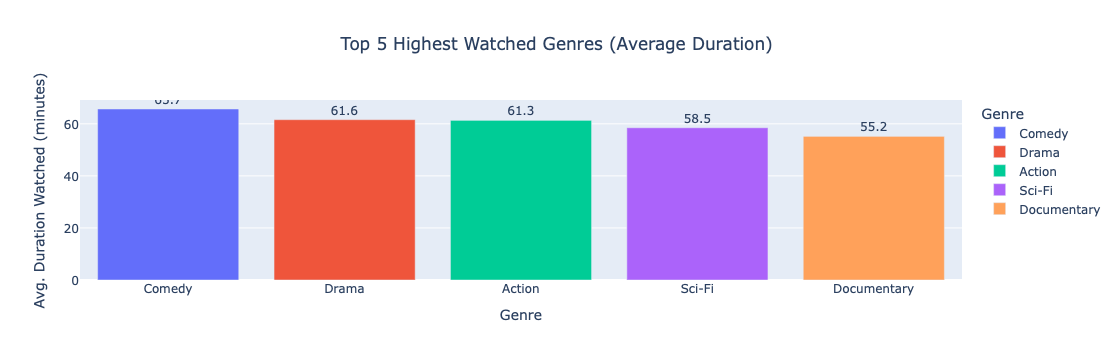

In [138]:



streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)


retention_v = streaming_vs.groupby('Genre')['Duration_Watched_minutes_'].mean()


top_5_retention_t = retention_v.sort_values(ascending=False).head(5)



top_5_df = top_5_retention_t.reset_index()
top_5_df.columns = ['Genre', 'Average_Duration_Watched']


fig = px.bar(top_5_df, 
             x='Genre', 
             y='Average_Duration_Watched', color='Genre',            
             title='Top 5 Highest Watched Genres (Average Duration)',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched')



fig.update_layout(title_x=0.5, legend_title_text='Genre')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')


fig.show()


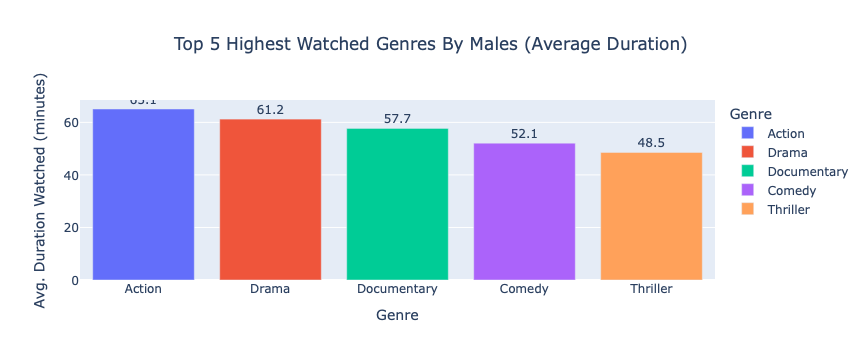

In [142]:



streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

male_viewers = streaming_vs[streaming_vs['Gender'] == 'Male']

retention_v = male_viewers.groupby('Genre')['Duration_Watched_minutes_'].mean()



top_5_retention_male = retention_v.sort_values(ascending=False).head(5)



top_5_df = top_5_retention_male.reset_index()
top_5_df.columns = ['Genre', 'Average_Duration_Watched']



fig = px.bar(top_5_df, 
             x='Genre', 
             y='Average_Duration_Watched', color='Genre',            
             title='Top 5 Highest Watched Genres By Males (Average Duration)',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched')



fig.update_layout(title_x=0.5, legend_title_text='Genre')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')



fig.show()


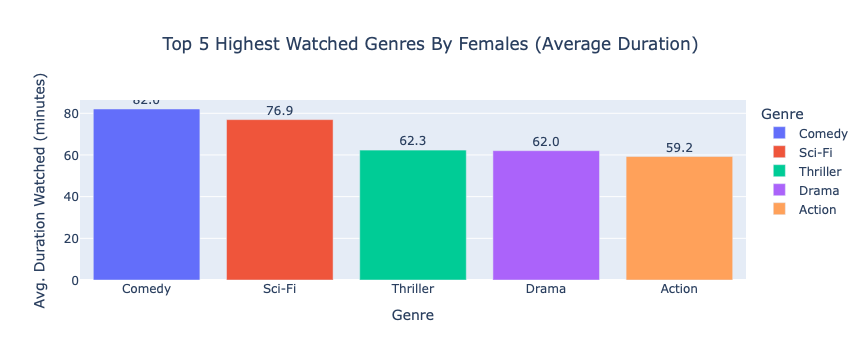

In [143]:



streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

female_viewers = streaming_vs[streaming_vs['Gender'] == 'Female']

retention_v = female_viewers.groupby('Genre')['Duration_Watched_minutes_'].mean()



top_5_retention_female = retention_v.sort_values(ascending=False).head(5)




top_5_df = top_5_retention_female.reset_index()
top_5_df.columns = ['Genre', 'Average_Duration_Watched']



fig = px.bar(top_5_df, 
             x='Genre', 
             y='Average_Duration_Watched', color='Genre',            
             title='Top 5 Highest Watched Genres By Females (Average Duration)',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched')



fig.update_layout(title_x=0.5, legend_title_text='Genre')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')



fig.show()


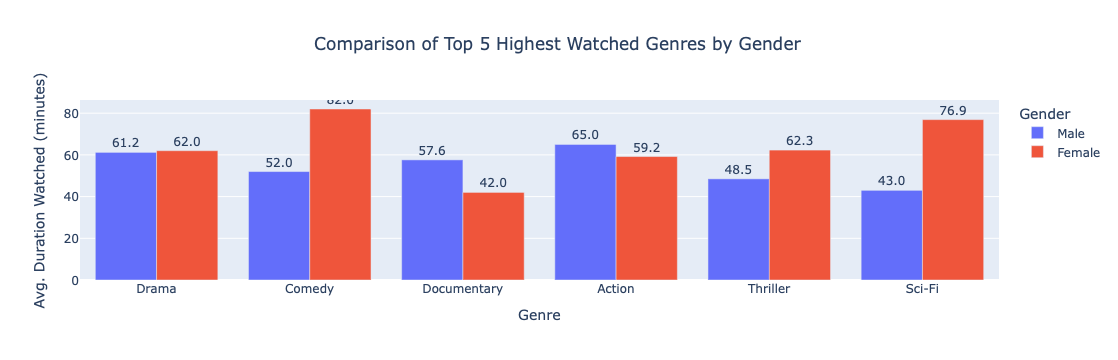

In [9]:
import pandas as pd
import plotly.express as px
# Simulated dataset for demonstration
# Replace this with actual grouped data from your streaming_vs DataFrame
male_data = {    'Genre': ['Drama', 'Comedy', 'Documentary', 'Action', 'Thriller', 'Sci-Fi'],
             'Gender': ['Male'] * 6,    
             'Average_Duration_Watched': [61.2, 52.0, 57.6, 65.0, 48.5, 43.0]}

female_data = {    'Genre': ['Drama', 'Comedy', 'Action', 'Sci-Fi', 'Thriller', 'Documentary'],    
               'Gender': ['Female'] * 6,    
               'Average_Duration_Watched': [62.0, 82.0, 59.2, 76.9, 62.3, 42.0]}

# Combine both datasets into one DataFrame
df_male = pd.DataFrame(male_data)
df_female = pd.DataFrame(female_data)
df_combined = pd.concat([df_male, df_female])

# Create grouped bar chart
fig = px.bar(df_combined, x='Genre', y='Average_Duration_Watched', color='Gender',             
             barmode='group',             
             title='Comparison of Top 5 Highest Watched Genres by Gender',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched')

# Customize layout
fig.update_layout(title_x=0.5)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.show()

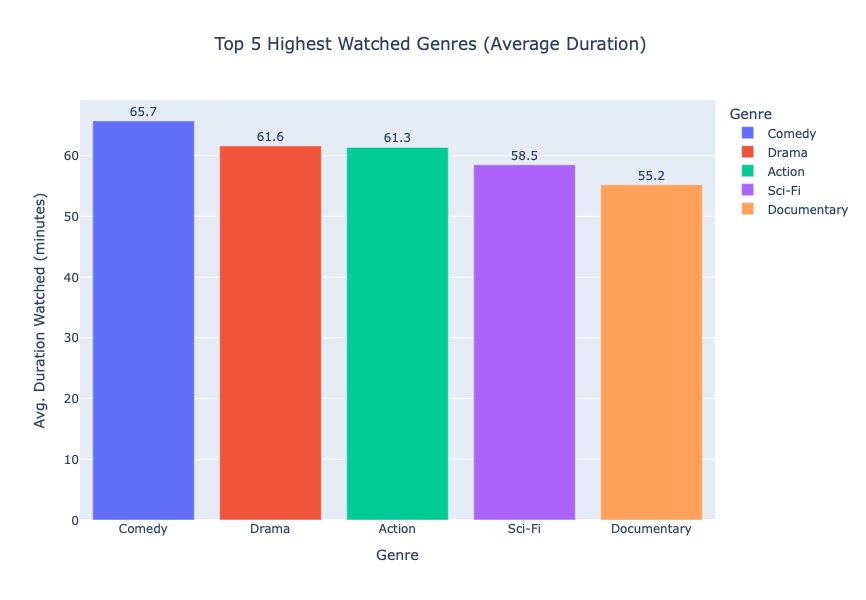

In [8]:



streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)


retention_v = streaming_vs.groupby('Genre')['Duration_Watched_minutes_'].mean()


top_5_retention_t = retention_v.sort_values(ascending=False).head(5)



top_5_df = top_5_retention_t.reset_index()
top_5_df.columns = ['Genre', 'Average_Duration_Watched']


fig = px.bar(top_5_df, 
             x='Genre', 
             y='Average_Duration_Watched', color='Genre',            
             title='Top 5 Highest Watched Genres (Average Duration)',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched', width=900, height=600)
                



fig.update_layout(title_x=0.5, legend_title_text='Genre')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')


fig.show()


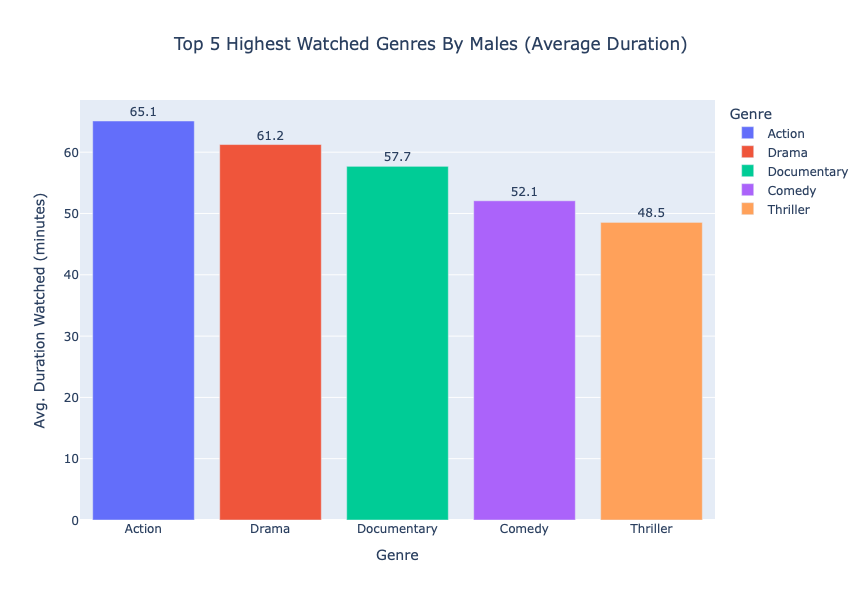

In [9]:



streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

male_viewers = streaming_vs[streaming_vs['Gender'] == 'Male']

retention_v = male_viewers.groupby('Genre')['Duration_Watched_minutes_'].mean()



top_5_retention_male = retention_v.sort_values(ascending=False).head(5)



top_5_df = top_5_retention_male.reset_index()
top_5_df.columns = ['Genre', 'Average_Duration_Watched']



fig = px.bar(top_5_df, 
             x='Genre', 
             y='Average_Duration_Watched', color='Genre',            
             title='Top 5 Highest Watched Genres By Males (Average Duration)',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched', width=900, height=600)



fig.update_layout(title_x=0.5, legend_title_text='Genre')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')



fig.show()


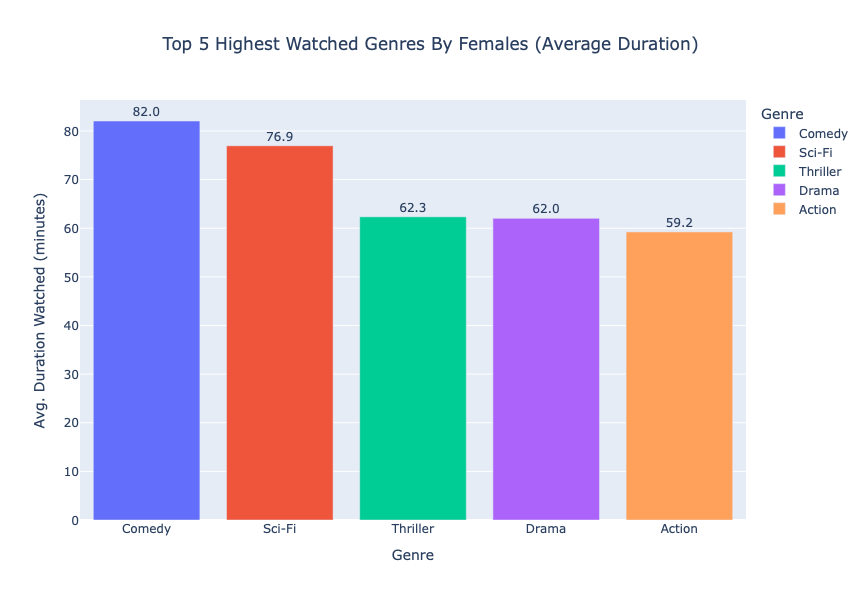

In [11]:



streaming_vs.columns = streaming_vs.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

female_viewers = streaming_vs[streaming_vs['Gender'] == 'Female']

retention_v = female_viewers.groupby('Genre')['Duration_Watched_minutes_'].mean()



top_5_retention_female = retention_v.sort_values(ascending=False).head(5)




top_5_df = top_5_retention_female.reset_index()
top_5_df.columns = ['Genre', 'Average_Duration_Watched']



fig = px.bar(top_5_df, 
             x='Genre', 
             y='Average_Duration_Watched', color='Genre',            
             title='Top 5 Highest Watched Genres By Females (Average Duration)',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched', width=900, height=600)



fig.update_layout(title_x=0.5, legend_title_text='Genre')
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')



fig.show()


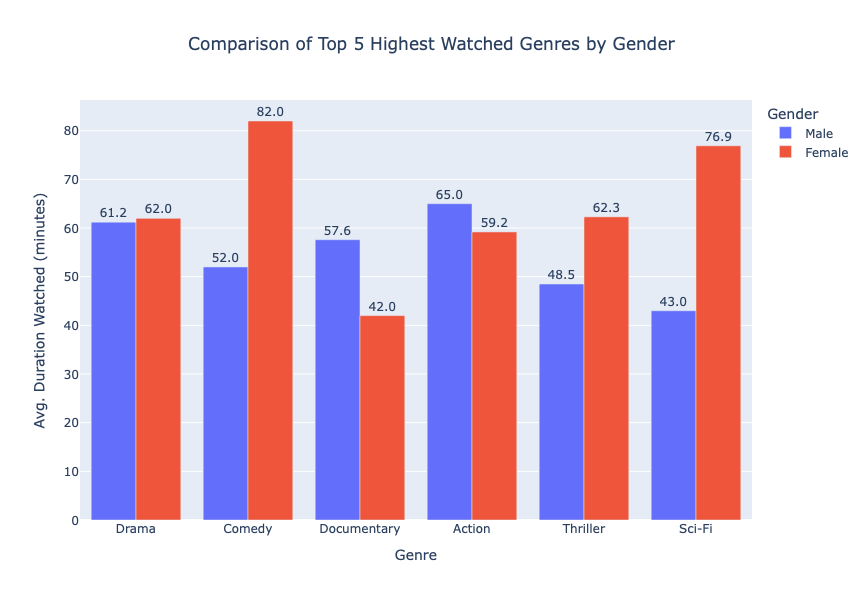

In [12]:
import pandas as pd
import plotly.express as px
# Simulated dataset for demonstration
# Replace this with actual grouped data from your streaming_vs DataFrame
male_data = {    'Genre': ['Drama', 'Comedy', 'Documentary', 'Action', 'Thriller', 'Sci-Fi'],
             'Gender': ['Male'] * 6,    
             'Average_Duration_Watched': [61.2, 52.0, 57.6, 65.0, 48.5, 43.0]}

female_data = {    'Genre': ['Drama', 'Comedy', 'Action', 'Sci-Fi', 'Thriller', 'Documentary'],    
               'Gender': ['Female'] * 6,    
               'Average_Duration_Watched': [62.0, 82.0, 59.2, 76.9, 62.3, 42.0]}

# Combine both datasets into one DataFrame
df_male = pd.DataFrame(male_data)
df_female = pd.DataFrame(female_data)
df_combined = pd.concat([df_male, df_female])

# Create grouped bar chart
fig = px.bar(df_combined, x='Genre', y='Average_Duration_Watched', color='Gender',             
             barmode='group',             
             title='Comparison of Top 5 Highest Watched Genres by Gender',             
             labels={'Average_Duration_Watched': 'Avg. Duration Watched (minutes)'},             
             text='Average_Duration_Watched', width=900, height=600)

# Customize layout
fig.update_layout(title_x=0.5)
fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')

fig.show()